# Duplicate Question Detection using NLP Techniques and Transformer Models (Quora Dataset)

- ### Problem Statement
Many users on platforms like Quora ask the same question in different ways. This creates duplicate content and makes it difficult to manage information.

The aim of this project is to build a system that can detect whether two questions have the same meaning or not. The system will use NLP techniques like text preprocessing, TF-IDF, and machine learning models, and also advanced models like BERT to improve accuracy.

This project helps in reducing duplicate questions and improving user experience.

- ### Dataset
    - **Source:** Quora Question Pairs (Kaggle)
    - **Size:** 404,290 question pairs
    - **Features:** `id`, `qid1`, `qid2`, `question1`, `question2`, `is_duplicate`
    - **Class Distribution:** 63% Non-Duplicate | 37% Duplicate

- ### Approach
    1. **EDA** — Understand data distribution, class imbalance, special characters, repeated questions
    2. **Preprocessing** — Normalize text, handle contractions, HTML tags, currency symbols
    3. **Baseline Modeling** — Bag of Words + Random Forest / XGBoost
    4. **Feature Engineering** — Word overlap, token ratios, fuzzy features, length-based features
    5. **Advanced Features** — Word2Vec embeddings for semantic representation



- ### **Importing Libraries**

In [1]:
import os
import re
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, roc_auc_score,confusion_matrix, classification_report


from bs4 import BeautifulSoup
from fuzzywuzzy import fuzz
from nltk.corpus import stopwords

%pip install Distance
import distance

%pip install gensim
from sklearn.feature_extraction.text import TfidfVectorizer 
from gensim.models import Word2Vec 
from sklearn.metrics.pairwise import cosine_similarity


from sklearn.model_selection import RandomizedSearchCV



import warnings
warnings.filterwarnings('ignore')



Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


# <u><center>**Exploratory Data Analysis**</center></u>

- ## **Data Loading:**


In [2]:
df = pd.read_csv("Data/train.csv")

- ## **Data Exploration:**

In [3]:
df.shape

(404290, 6)

In [4]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404290 entries, 0 to 404289
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404290 non-null  int64 
 1   qid1          404290 non-null  int64 
 2   qid2          404290 non-null  int64 
 3   question1     404289 non-null  object
 4   question2     404288 non-null  object
 5   is_duplicate  404290 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB



- ### **Checking Missing values:**


In [6]:
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

- ### **Checking Duplicacy:**

In [7]:
# duplicate rows
df.duplicated().sum()

np.int64(0)

- ### **Exploring Target Feature:**

In [8]:
# Distribution of duplicate and non-duplicate Questions

print(df['is_duplicate'].value_counts())
print(df['is_duplicate'].value_counts()/df['is_duplicate'].count()*100)

is_duplicate
0    255027
1    149263
Name: count, dtype: int64
is_duplicate
0    63.080215
1    36.919785
Name: count, dtype: float64


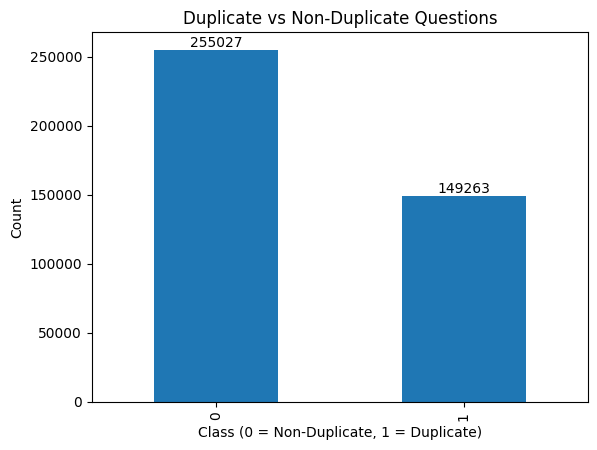

In [9]:
import matplotlib.pyplot as plt

ax = df['is_duplicate'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0])
plt.title("Duplicate vs Non-Duplicate Questions")
plt.xlabel("Class (0 = Non-Duplicate, 1 = Duplicate)")
plt.ylabel("Count")
plt.show()

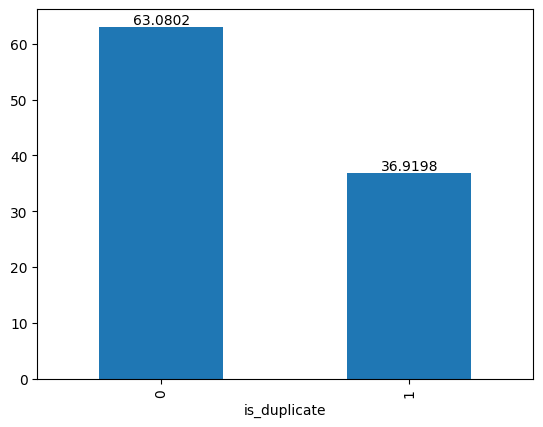

In [10]:
bx = (df['is_duplicate'].value_counts()/df['is_duplicate'].count()*100).plot(kind='bar')
bx.bar_label(bx.containers[0])
plt.show()

**INSIGHT:**
- Clearly shows class imbalance
- More non-duplicate (0)
- Fewer duplicate (1)



- ### **Finding Repeated Questions:**

In [11]:
# Repeated Questions

qid = pd.Series(df['qid1'].tolist() + df['qid2'].tolist())
print("Number of unique questions:", np.unique(qid).shape[0])
x = qid.value_counts()>1
print("Number of questions getting repeated:", x[x].shape[0])

Number of unique questions: 537933
Number of questions getting repeated: 111780


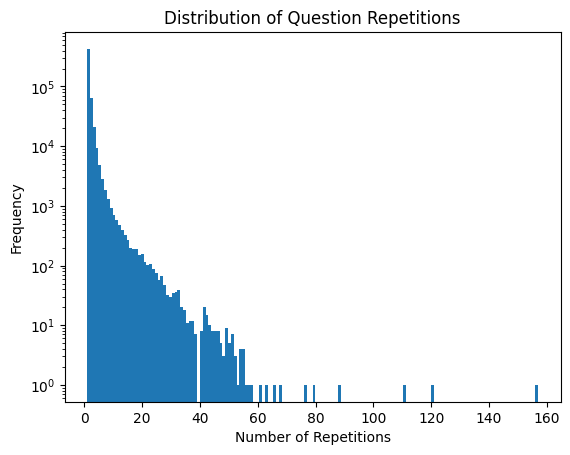

In [12]:
# Repeated Questions Distribution

plt.hist(qid.value_counts(), bins=160)
plt.title("Distribution of Question Repetitions")
plt.xlabel("Number of Repetitions")
plt.ylabel("Frequency")
plt.yscale('log')  
plt.show()

**INSIGHT:**
- Few questions are repeated many times
- Most questions appear once




# <u><center>**Feature Extraction**</center></u>

In [13]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [14]:
df.sample(10)

,id,qid1,qid2,question1,question2,is_duplicate
103303,103303,170771,170772,Where can I get to buy LSD drug?,How would I buy LSD?,0
281124,281124,162068,76778,When is good time to visit Italy?,What is the best time to visit Italy?,1
309764,309764,269193,262016,How can calculate moles hydrogen?,How do you calculate the moles of acid?,0
149849,149849,235955,235956,What single thing would most improve the educa...,What measures would you take to improve the ed...,0
380082,380082,8800,2509,What as your reaction when your heard about th...,What do you think of abolishing 500 and 1000 R...,1
222343,222343,329878,329879,How can I meet Chielly Goldshmid?,What would be the value of the dollar in the n...,0
276902,276902,395909,57487,"When is the best time to do yoga, in the morni...",When is the best time of day to do yoga?,1
321057,321057,446712,446713,What are the (ancient) Romans beliefs on the a...,Were the Ancient Greeks and Romans white?,0
294951,294951,416933,416934,What are some significant three word phrases?,What is an alternate term for the phrase ' by ...,0
332069,332069,11708,24723,How can I get traffic in my website?,How can I increase the traffic on my website?,1


In [15]:
new_df = df.sample(30000,random_state=42)

In [16]:
# missing values

new_df.isnull().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [17]:
df_clean = new_df.dropna(subset=["question1", "question2"])
ques_df = df_clean[["question1", "question2"]]

In [18]:
ques_df = new_df[['question1','question2']]
ques_df.head()

,question1,question2
8067,How do I play Pokémon GO in Korea?,How do I play Pokémon GO in China?
368101,What are some of the best side dishes for crab...,What are some good side dishes for buffalo chi...
70497,Which is more advisable and better material fo...,What is the best server setup for buddypress?
226567,How do I improve logical programming skills?,How can I improve my logical skills for progra...
73186,How close we are to see 3rd world war?,How close is a World War III?


In [19]:
from sklearn.feature_extraction.text import CountVectorizer

# merge texts
questions = list(ques_df['question1']) + list(ques_df['question2'])

cv = CountVectorizer(max_features=3000)
q1_arr, q2_arr = np.vsplit(cv.fit_transform(questions).toarray(), 2)

In [20]:
temp_df1 = pd.DataFrame(q1_arr, index= ques_df.index)
temp_df2 = pd.DataFrame(q2_arr, index= ques_df.index)
temp_df = pd.concat([temp_df1, temp_df2], axis=1)
temp_df.shape

(30000, 6000)

In [21]:
temp_df


,0,1,2,3,4,5,6,7,8,9,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
8067,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
368101,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
70497,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
226567,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
73186,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81275,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
273382,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
142371,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
79120,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
temp_df['is_duplicate'] = new_df['is_duplicate']

In [23]:
temp_df.head()

,0,1,2,3,4,5,6,7,8,9,...,2991,2992,2993,2994,2995,2996,2997,2998,2999,is_duplicate
8067,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
368101,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
70497,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
226567,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
73186,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


- ## **Train-Test Split:** 

In [24]:

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(temp_df.iloc[:,0:-1].values,temp_df.iloc[:,-1].values,test_size=0.2,random_state=1)


- ## **Model Building and Model Evaluation:** 

In [25]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
temp_rf_score = accuracy_score(y_test,y_pred)

In [26]:
temp_rf_score

0.7416666666666667

In [27]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train,y_train)
y_pred = xgb.predict(X_test)
temp_xgb_score =accuracy_score(y_test,y_pred)

In [28]:
temp_xgb_score

0.7273333333333334

In [29]:
RandomForestClassifier()

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [30]:
rf_improved = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    max_features='sqrt',
    min_samples_split=5,
    random_state=42
)
rf_improved.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print("rf_improved_accuracy_score",accuracy_score(y_test,y_pred))

rf_improved_accuracy_score 0.7416666666666667
